# OMOP Data Quality Scorecard

`src/quality/dqd_checks.py` implements a subset of the OHDSI Data Quality
Dashboard: completeness, conformance, plausibility, and temporal-consistency
checks against the loaded warehouse. This notebook runs the full suite and
renders it as a scorecard — one look at which table/category combinations are
solid and which need attention, rather than scrolling a log of 20 pass/fail
lines.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, "..")
sys.path.insert(0, ".")
from src.config.settings import settings

# Jupyter's kernel CWD is this notebook's own folder, but settings.duckdb_path
# defaults to a path relative to CWD — left alone, that resolves to
# notebooks/data/... and every query below would silently open a fresh,
# empty database instead of the real one at the repo root.
settings.duckdb_path = Path("../data/processed/omop_demo.duckdb")
import pandas as pd

from src.quality.dqd_checks import DQDChecker

checker = DQDChecker()
checker.run_all()
df = checker.summary_dataframe()
checker.engine.dispose()
df[["table", "category", "check", "metric", "threshold", "passed", "severity"]]

2026-08-27 11:54:00.611 | INFO     | src.quality.dqd_checks:run_all:186 - Running OMOP DQD quality checks


2026-08-27 11:54:00.717 | INFO     | src.quality.dqd_checks:run_all:222 - DQD complete: 20 passed, 0 failed


2026-08-27 11:54:00.718 | SUCCESS  | src.quality.dqd_checks:run_all:224 - [PASS] completeness_person_id on person: 1.00 (threshold: 0.99) [critical]


2026-08-27 11:54:00.719 | SUCCESS  | src.quality.dqd_checks:run_all:224 - [PASS] completeness_gender_concept_id on person: 1.00 (threshold: 0.99) [critical]


2026-08-27 11:54:00.719 | SUCCESS  | src.quality.dqd_checks:run_all:224 - [PASS] completeness_year_of_birth on person: 1.00 (threshold: 0.99) [critical]


...

2026-08-27 11:54:00.727 | SUCCESS  | src.quality.dqd_checks:run_all:224 - [PASS] plausible_range_year_of_birth on person: 1.00 (threshold: 0.99) [warning]


2026-08-27 11:54:00.727 | SUCCESS  | src.quality.dqd_checks:run_all:224 - [PASS] temporal_order_visit_start_date_before_visit_end_date on visit_occurrence: 1.00 (threshold: 0.99) [critical]


2026-08-27 11:54:00.728 | SUCCESS  | src.quality.dqd_checks:run_all:224 - [PASS] temporal_order_drug_exposure_start_date_before_drug_exposure_end_date on drug_exposure: 1.00 (threshold: 0.99) [critical]


2026-08-27 11:54:00.728 | SUCCESS  | src.quality.dqd_checks:run_all:224 - [PASS] temporal_order_condition_start_date_before_condition_end_date on condition_occurrence: 1.00 (threshold: 0.99) [critical]


,table,category,check,metric,threshold,passed,severity
0,person,completeness,completeness_person_id,1.000000,0.99,True,critical
1,person,completeness,completeness_gender_concept_id,1.000000,0.99,True,critical
2,person,completeness,completeness_year_of_birth,1.000000,0.99,True,critical
3,visit_occurrence,completeness,completeness_visit_occurrence_id,1.000000,0.99,True,critical
4,visit_occurrence,completeness,completeness_person_id,1.000000,0.99,True,critical
5,visit_occurrence,completeness,completeness_visit_start_date,1.000000,0.99,True,critical
6,condition_occurrence,completeness,completeness_condition_occurrence_id,1.000000,0.99,True,critical
7,condition_occurrence,completeness,completeness_person_id,1.000000,0.99,True,critical
8,condition_occurrence,completeness,completeness_condition_concept_id,1.000000,0.99,True,critical
9,drug_exposure,completeness,completeness_drug_exposure_id,1.000000,0.99,True,critical


## The chart

A 4x4 grid of monitor-style cards, one per (table, category), instead of a
heatmap — each card carries its own small EKG sparkline whose amplitude drops
with the pass rate (a flatter trace reads as "less signal," the same way it
would on a real monitor), a monospace percentage readout, and a glowing status
dot. `condition_occurrence` / `completeness` reads below 100% for a real
reason, not a bug: `condition_end_date` is deliberately checked against a 30%
threshold rather than 99%, because most conditions in a real population are
chronic or still active — a *high* completeness rate there would be the
surprising result, not a low one.


2026-08-27 11:54:02.068 | INFO     | src.quality.dqd_checks:run_all:186 - Running OMOP DQD quality checks
2026-08-27 11:54:02.177 | INFO     | src.quality.dqd_checks:run_all:222 - DQD complete: 20 passed, 0 failed
2026-08-27 11:54:02.177 | SUCCESS  | src.quality.dqd_checks:run_all:224 - [PASS] completeness_person_id on person: 1.00 (threshold: 0.99) [critical]
2026-08-27 11:54:02.177 | SUCCESS  | src.quality.dqd_checks:run_all:224 - [PASS] completeness_gender_concept_id on person: 1.00 (threshold: 0.99) [critical]
2026-08-27 11:54:02.177 | SUCCESS  | src.quality.dqd_checks:run_all:224 - [PASS] completeness_year_of_birth on person: 1.00 (threshold: 0.99) [critical]
2026-08-27 11:54:02.177 | SUCCESS  | src.quality.dqd_checks:run_all:224 - [PASS] completeness_visit_occurrence_id on visit_occurrence: 1.00 (threshold: 0.99) [critical]
2026-08-27 11:54:02.177 | SUCCESS  | src.quality.dqd_checks:run_all:224 - [PASS] completeness_person_id on visit_occurrence: 1.00 (threshold: 0.99) [critical]

Saved docs/assets/visualizations/dqd_scorecard_heatmap.svg and dqd_scorecard_heatmap.png


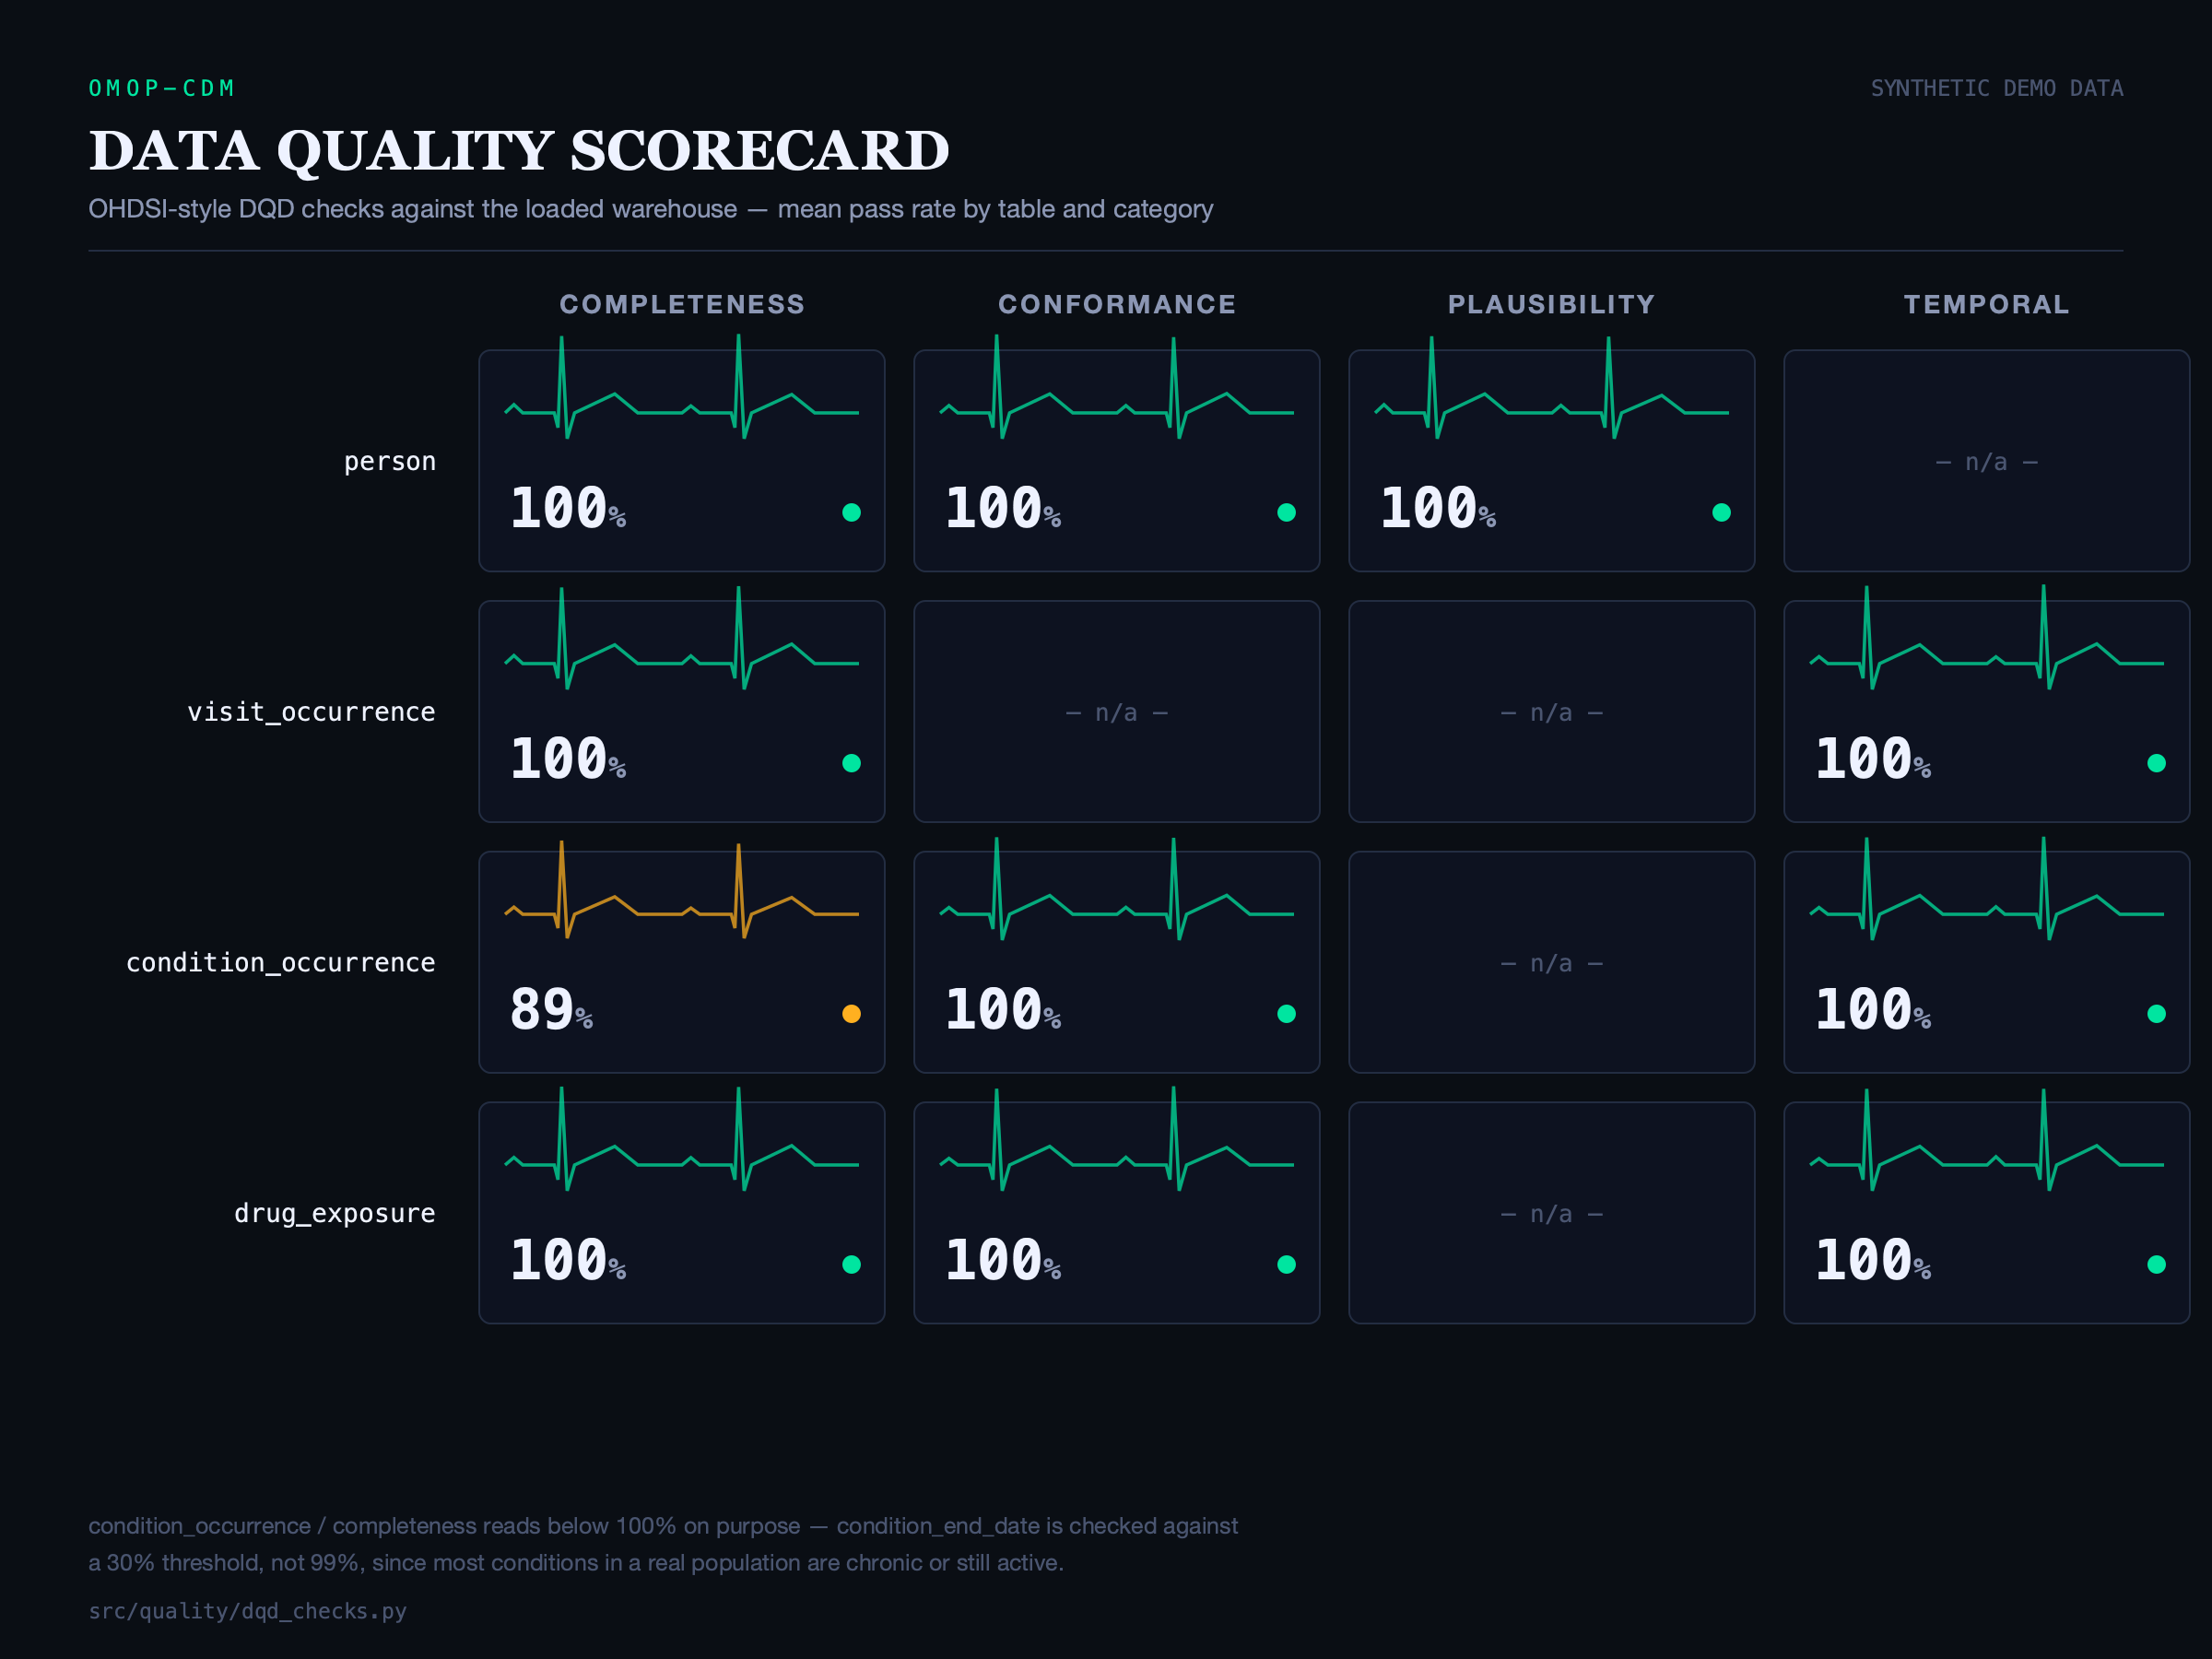

In [2]:
import subprocess
import sys
from IPython.display import Image

subprocess.run([sys.executable, "notebooks/build_dqd_scorecard.py"], cwd="..", check=True)
Image(filename="../docs/assets/visualizations/dqd_scorecard_heatmap.png")


## Reading this

Every cell here passed its own threshold — this is a clean run. The point of
building the scorecard around thresholds rather than a flat 100% bar is that
it stays meaningful when a real check *does* fail: a critical failure in
`main.py`'s quality stage halts the pipeline (`sys.exit(1)`) before load
results ever reach an analyst, and this scorecard is what a reviewer would
open next to see exactly where.